In [1]:
from functools import partial
import math

import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

In [2]:
# prevents numerical underflow issues for very small gain factor
# double precision also makes training curves nearly identical in last plot
torch.set_default_dtype(torch.float64)

First we load the MNIST dataset.

In [3]:
def load_data():
    train_ds = MNIST('data', train=True, transform=ToTensor(), download=True)
    train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
    return train_dl

Second, we create a 5-layer ReLU MLP. We set the bias to `false` to prevent exploding gradients. We also write a custom initialization function.

In [4]:
num_layers = 5

In [5]:
class MLP(nn.Module):
    def __init__(self, activation=nn.ReLU):
        super().__init__()
        self.layers = nn.Sequential()
        for i in range(num_layers-1):
            self.layers.add_module(f"Dense {i+1}", nn.LazyLinear(64))
            self.layers.add_module(f"Activation {i+1}", activation())
        self.layers.add_module(f"Dense {num_layers})", nn.LazyLinear(10))
        
    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return self.layers(x)

In [6]:
def custom_init(gain, m):
    if isinstance(m, nn.Linear):
        std = gain * math.sqrt(2 / m.weight.shape[1]) # He init
        nn.init.normal_(m.weight, std=std)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

def apply_init(model, gain):
    model(torch.zeros(1, 784)) # initialize lazy layers
    init_fn = partial(custom_init, gain)
    model.apply(init_fn)

In [7]:
lr = 0.05
num_epochs = 5

In [8]:
def mean(lst):
    return sum(lst) / len(lst)

def append(lst1, lst2, elem1, elem2):
    lst1.append(elem1)
    lst2.append(elem2)

In [9]:
def stats(model, X, y):
    logits = model(X)
    loss = F.cross_entropy(logits, y)
    accuracy = (logits.argmax(dim=1) == y).float().mean()
    return loss, accuracy

def train_step(opt, model, X, y):
    loss, accuracy = stats(model, X, y)
    loss.backward()
    opt.step()
    return loss.item(), accuracy.item()

In [10]:
def get_grads(model):
    wg, bg = [], []
    for m in model.modules():
        if isinstance(m, nn.Linear):
            wg.append(m.weight.grad.std())
            bg.append(m.bias.grad.std())
    return wg, bg

In [11]:
def train_model(activation=nn.ReLU):
    torch.manual_seed(0)
    train_dl = load_data()
    model = MLP(activation=activation)
    apply_init(model, gain=1)
    opt = torch.optim.SGD(model.parameters(), lr)
    losses, accuracies = [], []
    weight_grads, bias_grads = [], []
    for _ in range(num_epochs):
        for i, (X, y) in enumerate(train_dl):
            loss, acc = train_step(opt, model, X, y)
            append(losses, accuracies, loss, acc)
            wg, bg = get_grads(model)
            append(weight_grads, bias_grads, wg, bg)
            opt.zero_grad()                 
    return losses, accuracies, weight_grads, bias_grads

In [12]:
losses, accuracies, wg, bg = train_model()

In [13]:
losses_tanh, accuracies_tanh, wg_tanh, bg_tanh = train_model(activation=nn.Tanh)

In [14]:
losses_sigmoid, accuracies_sigmoid, wg_sigmoid, bg_sigmoid = train_model(activation=nn.Sigmoid)

In [15]:
wg = torch.tensor(wg).transpose(0, 1)
bg = torch.tensor(bg).transpose(0, 1)
wg_tanh = torch.tensor(wg_tanh).transpose(0, 1)
bg_tanh = torch.tensor(bg_tanh).transpose(0, 1)
wg_sigmoid = torch.tensor(wg_sigmoid).transpose(0, 1)
bg_sigmoid = torch.tensor(bg_sigmoid).transpose(0, 1)

In [16]:
print(wg.shape)

torch.Size([5, 2345])


In [17]:
print(wg[:,0])
print(wg_tanh[:,0])
print(wg_sigmoid[:,0])
print(bg[:,0])
print(bg_tanh[:,0])
print(bg_sigmoid[:,0])

tensor([0.0075, 0.0074, 0.0061, 0.0052, 0.0156])
tensor([0.0100, 0.0100, 0.0091, 0.0088, 0.0224])
tensor([8.5917e-05, 4.4988e-04, 1.2341e-03, 3.5609e-03, 3.5176e-02])
tensor([0.0260, 0.0222, 0.0151, 0.0139, 0.0391])
tensor([0.0249, 0.0189, 0.0153, 0.0136, 0.0312])
tensor([0.0003, 0.0009, 0.0023, 0.0073, 0.0675])


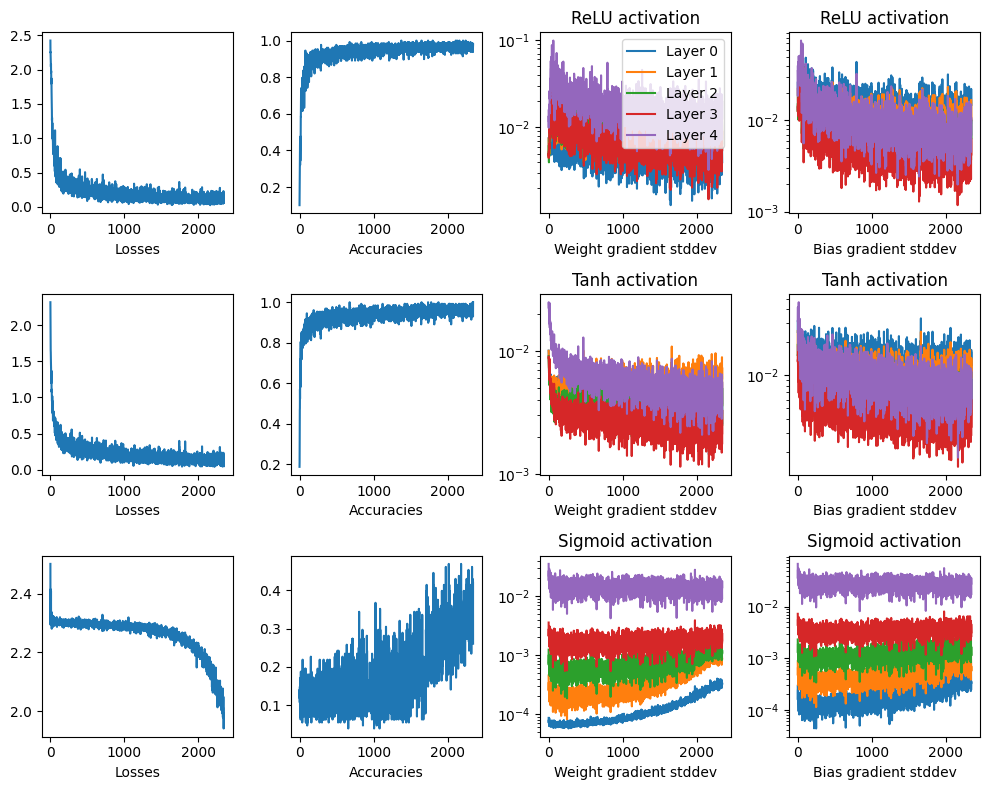

In [18]:
fig, axs = plt.subplots(nrows=3, ncols=4, squeeze=True, figsize=(10, 8))

axs[0, 0].plot(losses)
axs[0, 1].plot(accuracies)
for i in range(wg.shape[0]):
    axs[0, 2].plot(wg[i], label=f"Layer {i}")
    axs[0, 3].plot(bg[i])
axs[0, 2].set_yscale('log')
axs[0, 3].set_yscale('log')

axs[1, 0].plot(losses_tanh)
axs[1, 1].plot(accuracies_tanh)
for i in range(wg_tanh.shape[0]):
    axs[1, 2].plot(wg_tanh[i])
    axs[1, 3].plot(bg_tanh[i])
axs[1, 2].set_yscale('log')
axs[1, 3].set_yscale('log')

axs[2, 0].plot(losses_sigmoid)
axs[2, 1].plot(accuracies_sigmoid)
for i in range(wg_sigmoid.shape[0]):
    axs[2, 2].plot(wg_sigmoid[i])
    axs[2, 3].plot(bg_sigmoid[i])
axs[2, 2].set_yscale('log')
axs[2, 3].set_yscale('log')

axs[0, 0].set_xlabel("Losses")
axs[0, 1].set_xlabel("Accuracies")
axs[1, 0].set_xlabel("Losses")
axs[1, 1].set_xlabel("Accuracies")
axs[2, 0].set_xlabel("Losses")
axs[2, 1].set_xlabel("Accuracies")
axs[0, 2].set_xlabel("Weight gradient stddev")
axs[0, 3].set_xlabel("Bias gradient stddev")
axs[1, 2].set_xlabel("Weight gradient stddev")
axs[1, 3].set_xlabel("Bias gradient stddev")
axs[2, 2].set_xlabel("Weight gradient stddev")
axs[2, 3].set_xlabel("Bias gradient stddev")
axs[0, 2].set_title("ReLU activation")
axs[0, 3].set_title("ReLU activation")
axs[1, 2].set_title("Tanh activation")
axs[1, 3].set_title("Tanh activation")
axs[2, 2].set_title("Sigmoid activation")
axs[2, 3].set_title("Sigmoid activation")

axs[0, 2].legend()
fig.tight_layout()
#plt.savefig("gradients_over_time.png")
plt.show()